# Semantic Bounding-Box CutMix

Ex01에서 사용한 DeepLabV3 semantic segmentation을 Stanford Dogs 분류 실험에 연결합니다.
DeepLab이 예측한 `dog` mask를 직접 붙이는 대신, mask 전체를 포함하는 최소 bounding box를
구하고 그 사각형 이미지 영역 전체를 다른 이미지의 임의 위치에 붙입니다.

- 분류 모델: ImageNet pretrained ResNet-50
- image augmentation: Basic (horizontal flip 50% + brightness jitter 0.1)
- batch mixing: Semantic Bounding-Box CutMix, batch 적용 요청 확률 `p=0.5`
- alpha: 사용하지 않음
- label weight: 실제 붙인 bounding-box 면적
- epoch 20, seed 42, SGD, learning rate 0.001

기존 mask cache와 완료된 Semantic Mask CutMix 결과는 읽기 전용으로 재사용합니다.

> 새 mask를 생성하지 않습니다. 커널을 재시작한 뒤 위에서부터 순서대로 실행하세요.


## 1. 환경 및 경로 설정

mask cache와 Semantic CutMix 결과는 기존 실험과 분리된 폴더에 저장합니다.
DeepLab과 ResNet-50 pretrained weight는 로컬 PyTorch cache를 사용합니다.


In [1]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision.datasets import ImageFolder
from torchvision.models.segmentation import (
    DeepLabV3_ResNet101_Weights,
    deeplabv3_resnet101,
)


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SEED = 42
EPOCHS = 20
BATCH_SIZE = 16
MASK_BATCH_SIZE = 8
LEARNING_RATE = 0.001
MIX_PROBABILITY = 0.5
NUM_WORKERS = 2
COOLDOWN_EVERY_EPOCHS = 5
COOLDOWN_SECONDS = 60
IMAGE_SIZE = (224, 224)
SEGMENTATION_SIZE = (520, 520)
DOG_CLASS_ID = 12

DATASET_DIR = Path("~/datasets/stanfordimagenetdogs/Images").expanduser()
RESULT_DIR = Path("results_resnet50_segbboxcutmix")
MASK_CACHE_DIR = Path("results_resnet50_segcutmix")
MASK_DIR = MASK_CACHE_DIR / "masks"
MASK_STATS_PATH = MASK_CACHE_DIR / "mask_statistics.csv"
MASK_CONFIG_PATH = MASK_CACHE_DIR / "mask_cache_config.json"
HISTORY_PATH = RESULT_DIR / "training_history.csv"
CHECKPOINT_PATH = RESULT_DIR / "semantic_bbox_cutmix_best.pt"
EXPERIMENT_CONFIG_PATH = RESULT_DIR / "experiment_config.json"
COMPARISON_PATH = RESULT_DIR / "comparison.png"

REFERENCE_SUMMARY_PATH = Path(
    "results_resnet50_aug_alpha02_p05/experiment_summary.csv"
)
REFERENCE_EXPERIMENT = "basic_cutmix_alpha0.2_p0.5"
SEMANTIC_MASK_CHECKPOINT_PATH = Path(
    "results_resnet50_segcutmix/semantic_cutmix_best.pt"
)

# True로 바꾸면 checkpoint가 있어도 Bounding-Box CutMix를 처음부터 다시 학습합니다.
RETRAIN = False

RESULT_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Device: {DEVICE}")
print(f"Dataset: {DATASET_DIR}")
print(f"Mask cache: {MASK_DIR.resolve()}")
print(f"Results: {RESULT_DIR.resolve()}")

Device: cuda
Dataset: /home/thkim0/datasets/stanfordimagenetdogs/Images
Mask cache: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_segcutmix/masks
Results: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex03/results_resnet50_segbboxcutmix


## 2. 데이터 분할과 기본 transform

기존 augmentation 실험과 같은 `58.3% / 41.7%` split과 seed를 사용합니다.
분류 입력은 항상 `224×224`이며 normalization도 기존 실험과 동일합니다.


In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"데이터셋을 찾을 수 없습니다: {DATASET_DIR}")


def classification_transform():
    return transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5],
        ),
    ])


full_dataset = ImageFolder(
    root=DATASET_DIR,
    transform=classification_transform(),
)
total_size = len(full_dataset)
train_size = int(0.583 * total_size)
val_size = total_size - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=split_generator,
)

class_names = full_dataset.classes
num_classes = len(class_names)


def indices_fingerprint(indices):
    index_array = np.asarray(list(indices), dtype=np.int64)
    return hashlib.sha256(index_array.tobytes()).hexdigest()


train_indices_sha256 = indices_fingerprint(train_subset.indices)
val_indices_sha256 = indices_fingerprint(val_subset.indices)

print(f"Classes: {num_classes}")
print(f"Total: {total_size:,}")
print(f"Train: {len(train_subset):,} | Validation: {len(val_subset):,}")
print(f"Train indices SHA256: {train_indices_sha256}")
print(f"Validation indices SHA256: {val_indices_sha256}")

Classes: 120
Total: 20,580
Train: 11,998 | Validation: 8,582
Train indices SHA256: 77811abc456327ae4a99911df61fc926fd75541cedff92bdda2aef045a247492
Validation indices SHA256: c718b1070073d063d393f0d926409ad57a9e70b8534c5212d9a04bf3ca2c1ad1


## 3. 기존 DeepLab dog mask cache 검증

`node-2-seg.ipynb`에서 생성한 20,580장의 mask를 그대로 재사용합니다.
mask는 bounding box의 좌표를 찾는 용도로만 사용하며, 실제 합성에서는 bounding box 안의
이미지 픽셀 전체를 교체합니다.

cache 설정이 현재 코드와 다르거나 mask가 누락되면 오류를 발생시킵니다.


In [3]:
segmentation_weights = DeepLabV3_ResNet101_Weights.DEFAULT
segmentation_categories = segmentation_weights.meta["categories"]
assert segmentation_categories[DOG_CLASS_ID] == "dog"

mask_cache_config = {
    "model": "deeplabv3_resnet101",
    "weights": segmentation_weights.name,
    "dog_class_id": DOG_CLASS_ID,
    "dog_class_name": segmentation_categories[DOG_CLASS_ID],
    "segmentation_size": list(SEGMENTATION_SIZE),
    "mask_size": list(IMAGE_SIZE),
    "dataset_dir": str(DATASET_DIR.resolve()),
    "dataset_samples": total_size,
}

if MASK_CONFIG_PATH.exists():
    saved_mask_config = json.loads(
        MASK_CONFIG_PATH.read_text(encoding="utf-8")
    )
    if saved_mask_config != mask_cache_config:
        raise RuntimeError(
            "기존 mask cache 설정이 현재 설정과 다릅니다. "
            f"{MASK_DIR}와 {MASK_CONFIG_PATH}를 삭제한 뒤 다시 실행하세요."
        )
else:
    MASK_CONFIG_PATH.write_text(
        json.dumps(mask_cache_config, indent=2),
        encoding="utf-8",
    )


def mask_path_for_index(dataset_index):
    return MASK_DIR / f"{dataset_index:05d}.png"


segmentation_transform = transforms.Compose([
    transforms.Resize(SEGMENTATION_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class MaskGenerationDataset(Dataset):
    def __init__(self, samples, dataset_indices):
        self.samples = samples
        self.dataset_indices = list(dataset_indices)

    def __len__(self):
        return len(self.dataset_indices)

    def __getitem__(self, item):
        dataset_index = self.dataset_indices[item]
        image_path, _ = self.samples[dataset_index]
        image = Image.open(image_path).convert("RGB")
        return segmentation_transform(image), dataset_index


missing_mask_indices = [
    index
    for index in range(total_size)
    if not mask_path_for_index(index).exists()
]

print(f"Cached masks: {total_size - len(missing_mask_indices):,}")
print(f"Masks to generate: {len(missing_mask_indices):,}")

Cached masks: 20,580
Masks to generate: 0


모든 mask가 cache되어 있어 segmentation 추론을 건너뜁니다.
Dog mask detected: 20,154/20,580 (97.93%)
Detected mask ratio | mean=0.3218, std=0.1809, min=0.0000, max=0.9990


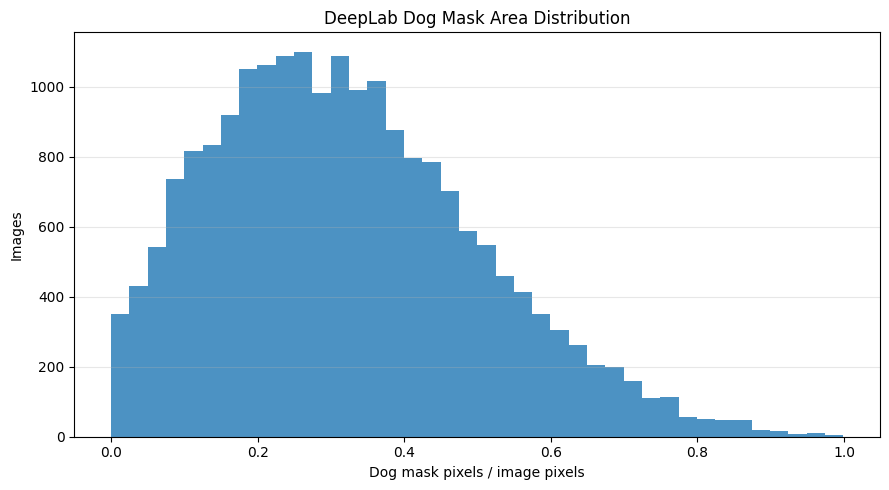

In [4]:
if missing_mask_indices:
    segmentation_model = deeplabv3_resnet101(
        weights=segmentation_weights
    ).to(DEVICE)
    segmentation_model.eval()

    mask_loader = DataLoader(
        MaskGenerationDataset(
            full_dataset.samples,
            missing_mask_indices,
        ),
        batch_size=MASK_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    with torch.no_grad():
        for batch_index, (images, dataset_indices) in enumerate(mask_loader, 1):
            images = images.to(DEVICE, non_blocking=True)
            logits = segmentation_model(images)["out"]
            predictions = logits.argmax(dim=1)
            dog_masks = predictions.eq(DOG_CLASS_ID).float().unsqueeze(1)
            dog_masks = F.interpolate(
                dog_masks,
                size=IMAGE_SIZE,
                mode="nearest",
            ).squeeze(1).bool().cpu().numpy()

            for dog_mask, dataset_index in zip(
                dog_masks,
                dataset_indices.tolist(),
            ):
                mask_image = Image.fromarray(
                    dog_mask.astype(np.uint8) * 255,
                    mode="L",
                )
                mask_image.save(mask_path_for_index(dataset_index))

            if batch_index % 100 == 0 or batch_index == len(mask_loader):
                completed = min(
                    batch_index * MASK_BATCH_SIZE,
                    len(missing_mask_indices),
                )
                print(
                    f"Mask generation: {completed:,}/"
                    f"{len(missing_mask_indices):,}"
                )

    segmentation_model.to("cpu")
    del segmentation_model, mask_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("모든 mask가 cache되어 있어 segmentation 추론을 건너뜁니다.")

missing_after_generation = [
    index
    for index in range(total_size)
    if not mask_path_for_index(index).exists()
]
assert not missing_after_generation

mask_rows = []
total_pixels = IMAGE_SIZE[0] * IMAGE_SIZE[1]
for dataset_index, (image_path, label) in enumerate(full_dataset.samples):
    mask = np.asarray(
        Image.open(mask_path_for_index(dataset_index)).convert("L")
    ) > 0
    mask_pixels = int(mask.sum())
    mask_rows.append({
        "dataset_index": dataset_index,
        "image_path": image_path,
        "label": label,
        "class_name": class_names[label],
        "mask_pixels": mask_pixels,
        "mask_ratio": mask_pixels / total_pixels,
        "detected": mask_pixels > 0,
    })

mask_stats_df = pd.DataFrame(mask_rows)
mask_stats_df.to_csv(MASK_STATS_PATH, index=False)

detected_count = int(mask_stats_df["detected"].sum())
detected_ratio = mask_stats_df["detected"].mean()
detected_masks = mask_stats_df.loc[
    mask_stats_df["detected"],
    "mask_ratio",
]

print(
    f"Dog mask detected: {detected_count:,}/{total_size:,} "
    f"({100.0 * detected_ratio:.2f}%)"
)
print(
    f"Detected mask ratio | mean={detected_masks.mean():.4f}, "
    f"std={detected_masks.std():.4f}, "
    f"min={detected_masks.min():.4f}, "
    f"max={detected_masks.max():.4f}"
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(detected_masks, bins=40, color="tab:blue", alpha=0.8)
ax.set_title("DeepLab Dog Mask Area Distribution")
ax.set_xlabel("Dog mask pixels / image pixels")
ax.set_ylabel("Images")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 4. 이미지와 mask가 함께 움직이는 데이터셋

horizontal flip은 이미지와 mask에 동시에 적용합니다. Brightness jitter는 픽셀 색만
바꾸므로 이미지에만 적용합니다. validation에는 augmentation을 적용하지 않습니다.


In [5]:
class CachedMaskDogDataset(Dataset):
    def __init__(self, samples, indices, train=False):
        self.samples = samples
        self.indices = list(indices)
        self.train = train
        self.brightness_jitter = transforms.ColorJitter(brightness=0.1)
        self.to_classifier_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5],
            ),
        ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        dataset_index = self.indices[item]
        image_path, label = self.samples[dataset_index]

        image = Image.open(image_path).convert("RGB")
        image = TF.resize(image, IMAGE_SIZE)
        mask = Image.open(mask_path_for_index(dataset_index)).convert("L")
        if mask.size != (IMAGE_SIZE[1], IMAGE_SIZE[0]):
            mask = TF.resize(
                mask,
                IMAGE_SIZE,
                interpolation=transforms.InterpolationMode.NEAREST,
            )

        if self.train and torch.rand(1).item() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if self.train:
            image = self.brightness_jitter(image)

        image_tensor = self.to_classifier_tensor(image)
        mask_tensor = torch.from_numpy(
            (np.asarray(mask) > 0).copy()
        ).bool()

        assert image_tensor.shape == (3, *IMAGE_SIZE)
        assert mask_tensor.shape == IMAGE_SIZE
        return image_tensor, label, mask_tensor


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_loader(dataset, shuffle, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
        worker_init_fn=seed_worker,
    )


train_dataset = CachedMaskDogDataset(
    full_dataset.samples,
    train_subset.indices,
    train=True,
)
val_dataset = CachedMaskDogDataset(
    full_dataset.samples,
    val_subset.indices,
    train=False,
)

train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)

sample_images, sample_labels, sample_masks = next(iter(train_loader))
assert sample_images.shape[1:] == (3, *IMAGE_SIZE)
assert sample_masks.shape[1:] == IMAGE_SIZE
print(f"Image batch: {sample_images.shape}")
print(f"Mask batch: {sample_masks.shape}")

Image batch: torch.Size([16, 3, 224, 224])
Mask batch: torch.Size([16, 224, 224])


## 5. Semantic Bounding-Box CutMix

선택된 batch의 각 receiver는 다른 sample의 dog mask를 포함하는 최소 bounding box crop을
받습니다. 기존 Semantic Mask CutMix와 달리, 사각형 내부의 배경 픽셀까지 모두 교체합니다.

sample마다 bounding box 크기가 다르므로 `lam`도 sample별로 계산합니다. batch 안에 mask가
없는 donor가 하나라도 있으면 그 batch 전체의 mixing을 건너뜁니다.


In [6]:
def semantic_bbox_cutmix_batch(images, labels, masks):
    batch_size, _, height, width = images.shape
    if batch_size < 2:
        ones = torch.ones(batch_size, device=images.device)
        return images, labels, labels, ones, False

    # roll offset이 1 이상이므로 자기 자신을 donor로 선택하지 않습니다.
    offset = int(torch.randint(1, batch_size, (1,), device=images.device))
    donor_indices = torch.roll(
        torch.arange(batch_size, device=images.device),
        shifts=offset,
    )
    donor_masks = masks[donor_indices]

    # 계획대로 donor mask가 하나라도 없으면 batch 전체를 일반 CE로 처리합니다.
    if not donor_masks.flatten(1).any(dim=1).all():
        ones = torch.ones(batch_size, device=images.device)
        return images, labels, labels, ones, False

    mixed_images = images.clone()
    receiver_lams = torch.ones(batch_size, device=images.device)

    for receiver_index in range(batch_size):
        donor_index = donor_indices[receiver_index]
        donor_mask = masks[donor_index]
        coordinates = donor_mask.nonzero(as_tuple=False)

        y1, x1 = coordinates.min(dim=0).values
        y2, x2 = coordinates.max(dim=0).values + 1

        donor_crop = images[donor_index, :, y1:y2, x1:x2]
        mask_crop = donor_mask[y1:y2, x1:x2]
        crop_height, crop_width = mask_crop.shape

        max_top = height - crop_height
        max_left = width - crop_width
        paste_top = int(
            torch.randint(max_top + 1, (1,), device=images.device)
        )
        paste_left = int(
            torch.randint(max_left + 1, (1,), device=images.device)
        )

        target_region = mixed_images[
            receiver_index,
            :,
            paste_top:paste_top + crop_height,
            paste_left:paste_left + crop_width,
        ]
        target_region.copy_(donor_crop)

        donor_ratio = (crop_height * crop_width) / (height * width)
        receiver_lams[receiver_index] = 1.0 - donor_ratio

    assert mixed_images.shape == images.shape
    assert torch.all((0.0 <= receiver_lams) & (receiver_lams <= 1.0))
    assert torch.allclose(
        receiver_lams + (1.0 - receiver_lams),
        torch.ones_like(receiver_lams),
    )

    return (
        mixed_images,
        labels,
        labels[donor_indices],
        receiver_lams,
        True,
    )

## 6. Mask, Bounding Box, 합성 결과 시각화

빨간 영역은 DeepLab의 dog mask이고 노란 사각형은 그 mask를 모두 포함하는 최소 bounding
box입니다. `Extracted bbox`는 receiver에 실제로 붙는 사각형 전체를 표시합니다.

시각화용 난수는 `torch.random.fork_rng()` 안에서만 사용하므로 이후 학습의 random
state에는 영향을 주지 않습니다.


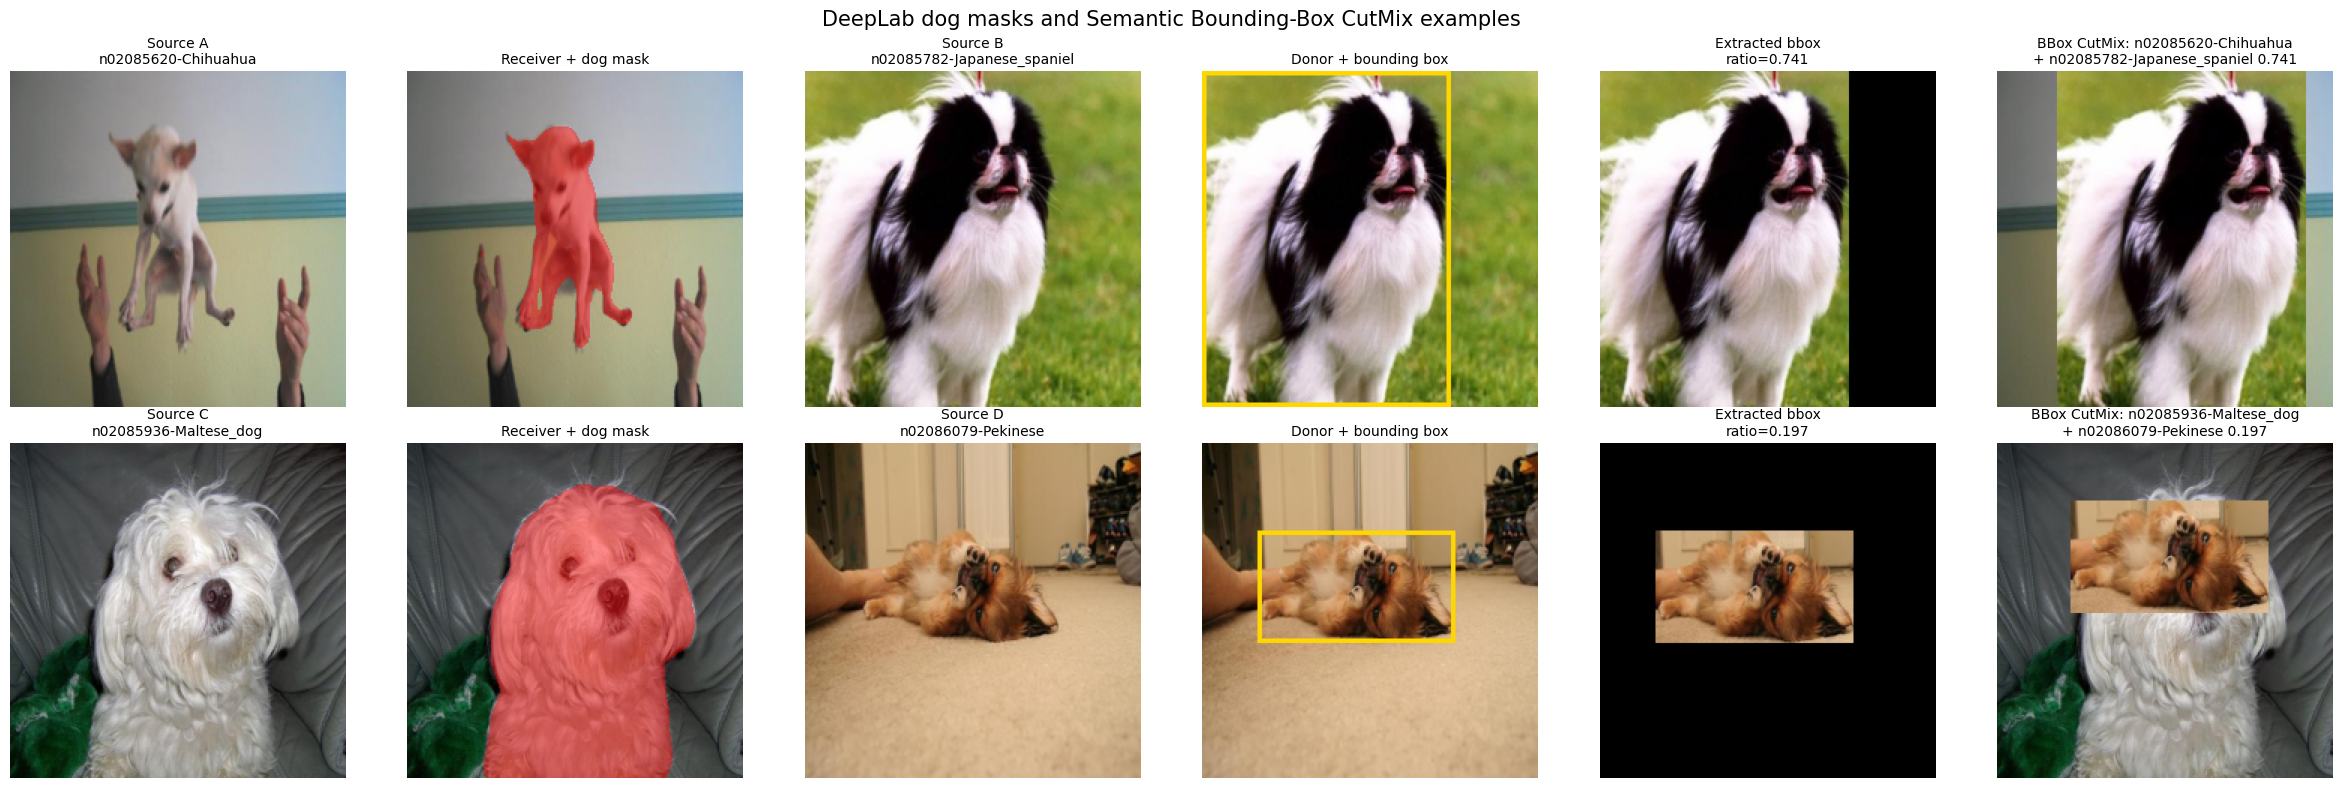

In [7]:
successful_train_rows = mask_stats_df.loc[
    mask_stats_df["dataset_index"].isin(train_subset.indices)
    & mask_stats_df["detected"]
].copy()

# node-2-final과 같이 서로 다른 label의 source 네 장을 선택합니다.
visualization_indices = (
    successful_train_rows
    .drop_duplicates(subset="label")
    .head(4)["dataset_index"]
    .astype(int)
    .tolist()
)
if len(visualization_indices) < 4:
    raise RuntimeError(
        "서로 다른 label을 가진 mask 검출 성공 이미지 네 장이 필요합니다."
    )


def load_visualization_sample(dataset_index):
    image_path, label = full_dataset.samples[dataset_index]
    image = TF.resize(
        Image.open(image_path).convert("RGB"),
        IMAGE_SIZE,
    )
    mask = TF.resize(
        Image.open(mask_path_for_index(dataset_index)).convert("L"),
        IMAGE_SIZE,
        interpolation=transforms.InterpolationMode.NEAREST,
    )
    mask_array = np.asarray(mask) > 0
    return image, label, mask_array


def add_mask_overlay(image, mask, color=(255, 0, 0), alpha=0.45):
    image_array = np.asarray(image).copy()
    color_array = np.asarray(color, dtype=np.float32)
    image_array[mask] = (
        (1.0 - alpha) * image_array[mask] + alpha * color_array
    ).astype(np.uint8)
    return image_array


def add_bbox_overlay(image, mask):
    image_array = np.asarray(image).copy()
    coordinates = np.argwhere(mask)
    y1, x1 = coordinates.min(axis=0)
    y2, x2 = coordinates.max(axis=0) + 1
    image_array[y1:y1 + 3, x1:x2] = (255, 215, 0)
    image_array[max(y2 - 3, y1):y2, x1:x2] = (255, 215, 0)
    image_array[y1:y2, x1:x1 + 3] = (255, 215, 0)
    image_array[y1:y2, max(x2 - 3, x1):x2] = (255, 215, 0)
    return image_array


def extract_bbox(image, mask):
    extracted = np.zeros((*IMAGE_SIZE, 3), dtype=np.uint8)
    image_array = np.asarray(image)
    coordinates = np.argwhere(mask)
    y1, x1 = coordinates.min(axis=0)
    y2, x2 = coordinates.max(axis=0) + 1
    extracted[y1:y2, x1:x2] = image_array[y1:y2, x1:x2]
    return extracted


def denormalize(image_tensor):
    return torch.clamp(image_tensor * 0.5 + 0.5, 0, 1)


visual_samples = [
    load_visualization_sample(index)
    for index in visualization_indices
]
pair_indices = [(0, 1), (2, 3)]

fig, axes = plt.subplots(
    len(pair_indices),
    6,
    figsize=(24, 8),
    squeeze=False,
)

for row, (receiver_index, donor_index) in enumerate(pair_indices):
    receiver_image, receiver_label, receiver_mask = visual_samples[
        receiver_index
    ]
    donor_image, donor_label, donor_mask = visual_samples[donor_index]

    image_batch = torch.stack([
        classification_transform()(receiver_image),
        classification_transform()(donor_image),
    ])
    mask_batch = torch.from_numpy(
        np.stack([receiver_mask, donor_mask])
    ).bool()
    label_batch = torch.tensor(
        [receiver_label, donor_label],
        dtype=torch.long,
    )

    # batch size가 2이므로 receiver 0의 donor는 항상 sample 1입니다.
    with torch.random.fork_rng():
        torch.manual_seed(SEED + 1000 + row)
        mixed_batch, _, donor_labels, visual_lams, applied = (
            semantic_bbox_cutmix_batch(
                image_batch,
                label_batch,
                mask_batch,
            )
        )
    assert applied
    assert donor_labels[0].item() == donor_label

    donor_ratio = 1.0 - visual_lams[0].item()
    display_items = [
        (
            np.asarray(receiver_image),
            f"Source {chr(65 + receiver_index)}\n"
            f"{class_names[receiver_label]}",
        ),
        (
            add_mask_overlay(receiver_image, receiver_mask),
            "Receiver + dog mask",
        ),
        (
            np.asarray(donor_image),
            f"Source {chr(65 + donor_index)}\n"
            f"{class_names[donor_label]}",
        ),
        (
            add_bbox_overlay(donor_image, donor_mask),
            "Donor + bounding box",
        ),
        (
            extract_bbox(donor_image, donor_mask),
            f"Extracted bbox\nratio={donor_ratio:.3f}",
        ),
        (
            denormalize(mixed_batch[0]).permute(1, 2, 0).numpy(),
            (
                f"BBox CutMix: {class_names[receiver_label]}\n"
                f"+ {class_names[donor_label]} {donor_ratio:.3f}"
            ),
        ),
    ]

    for col, (item, title) in enumerate(display_items):
        axes[row, col].imshow(item)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        f"Comparison {row + 1}",
        fontsize=12,
    )

fig.suptitle(
    "DeepLab dog masks and Semantic Bounding-Box CutMix examples",
    fontsize=15,
)
fig.tight_layout()
plt.show()


## 7. ResNet-50 초기값과 기존 실험 hash 검증

ImageNet pretrained ResNet-50과 새 FC layer를 한 번 초기화합니다. 기존 p=0.5 history가
있으면 초기 모델과 데이터 분할 hash가 동일한지 확인합니다.


In [8]:
set_seed()
base_model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)
initial_model_state = copy.deepcopy(base_model.state_dict())
del base_model


def state_dict_fingerprint(state_dict):
    digest = hashlib.sha256()
    for name in sorted(state_dict):
        tensor = state_dict[name].detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(tensor.dtype).encode("utf-8"))
        digest.update(np.asarray(tensor.shape, dtype=np.int64).tobytes())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


initial_model_sha256 = state_dict_fingerprint(initial_model_state)


def create_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(initial_model_state)
    return model


reference_history_path = Path(
    "results_resnet50_aug_alpha02_p05/histories/"
    "basic_cutmix_alpha0.2_p0.5.pt"
)
if reference_history_path.exists():
    reference_history = torch.load(
        reference_history_path,
        map_location="cpu",
    )
    assert reference_history["initial_model_sha256"] == initial_model_sha256
    assert reference_history["train_indices_sha256"] == train_indices_sha256
    assert reference_history["val_indices_sha256"] == val_indices_sha256
    print("기존 실험과 초기 모델 및 데이터 분할 hash가 일치합니다.")
else:
    print("참고 history가 없어 현재 hash만 기록합니다.")

print(f"Initial model SHA256: {initial_model_sha256}")

기존 실험과 초기 모델 및 데이터 분할 hash가 일치합니다.
Initial model SHA256: 0d7d077cf589e581e6b94d03e07a85d3911a46f683b9972684498327d005c960


## 8. sample별 bounding-box lam을 사용하는 학습 함수

bounding box 면적은 sample마다 다르므로 `CrossEntropyLoss(reduction="none")`으로
sample별 손실을 구한 뒤 각자의 `lam`으로 가중합니다.

- 요청 혼합률: `p=0.5`로 Bounding-Box CutMix를 시도한 batch 비율
- 실제 적용률: mask가 모두 존재해 실제 합성이 수행된 batch 비율
- mask 실패 batch: 요청했지만 donor mask가 없어 일반 CE로 처리한 batch 수


In [9]:
def evaluate(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in data_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            losses = criterion(outputs, labels)
            batch_size = labels.size(0)
            running_loss += losses.sum().item()
            correct += outputs.argmax(dim=1).eq(labels).sum().item()
            total += batch_size

    return running_loss / total, 100.0 * correct / total


def save_best_checkpoint(model, epoch, val_loss, val_accuracy):
    checkpoint = {
        "model_state_dict": {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        },
        "architecture": "resnet50",
        "num_classes": num_classes,
        "class_names": class_names,
        "epoch": epoch,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "seed": SEED,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "augmentation": "basic",
        "batch_mix": "semantic_bbox_cutmix",
        "mix_probability": MIX_PROBABILITY,
        "mix_alpha": None,
        "initial_model_sha256": initial_model_sha256,
        "train_indices_sha256": train_indices_sha256,
        "val_indices_sha256": val_indices_sha256,
        "mask_cache_config": mask_cache_config,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)


def train_semantic_bbox_cutmix(model):
    set_seed(SEED)
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(reduction="none")
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
    best_val_accuracy = float("-inf")
    history_rows = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        weighted_correct = 0.0
        total_samples = 0
        total_batches = 0
        requested_batches = 0
        applied_batches = 0
        mask_failure_batches = 0
        pasted_ratio_sum = 0.0
        pasted_ratio_samples = 0

        for images, labels, masks in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            total_batches += 1

            requested = random.random() < MIX_PROBABILITY
            if requested:
                requested_batches += 1
                (
                    model_images,
                    labels_a,
                    labels_b,
                    receiver_lams,
                    applied,
                ) = semantic_bbox_cutmix_batch(images, labels, masks)
                if applied:
                    applied_batches += 1
                    donor_ratios = 1.0 - receiver_lams
                    pasted_ratio_sum += donor_ratios.sum().item()
                    pasted_ratio_samples += labels.size(0)
                else:
                    mask_failure_batches += 1
            else:
                model_images = images
                labels_a = labels_b = labels
                receiver_lams = torch.ones(
                    labels.size(0),
                    device=DEVICE,
                )

            optimizer.zero_grad()
            outputs = model(model_images)
            losses_a = criterion(outputs, labels_a)
            losses_b = criterion(outputs, labels_b)
            losses = (
                receiver_lams * losses_a
                + (1.0 - receiver_lams) * losses_b
            )
            loss = losses.mean()
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += losses.sum().item()
            weighted_correct += (
                receiver_lams
                * predicted.eq(labels_a).float()
                + (1.0 - receiver_lams)
                * predicted.eq(labels_b).float()
            ).sum().item()
            total_samples += batch_size

        train_loss = running_loss / total_samples
        train_accuracy = 100.0 * weighted_correct / total_samples
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        requested_mix_ratio = requested_batches / total_batches
        actual_mix_ratio = applied_batches / total_batches
        mean_pasted_bbox_ratio = (
            pasted_ratio_sum / pasted_ratio_samples
            if pasted_ratio_samples
            else 0.0
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "total_batches": total_batches,
            "requested_mix_batches": requested_batches,
            "applied_mix_batches": applied_batches,
            "mask_failure_batches": mask_failure_batches,
            "requested_mix_ratio": requested_mix_ratio,
            "actual_mix_ratio": actual_mix_ratio,
            "mean_pasted_bbox_ratio": mean_pasted_bbox_ratio,
        }
        history_rows.append(row)
        pd.DataFrame(history_rows).to_csv(HISTORY_PATH, index=False)

        improved = val_accuracy > best_val_accuracy
        if improved:
            best_val_accuracy = val_accuracy
            save_best_checkpoint(
                model,
                epoch,
                val_loss,
                val_accuracy,
            )

        marker = " | BEST SAVED" if improved else ""
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.2f}% | "
            f"requested {requested_mix_ratio:.3f} | "
            f"applied {actual_mix_ratio:.3f} | "
            f"mask fail {mask_failure_batches} | "
            f"bbox area {mean_pasted_bbox_ratio:.3f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.2f}%{marker}"
        )

        if epoch % COOLDOWN_EVERY_EPOCHS == 0 and epoch < EPOCHS:
            print(f"GPU 냉각을 위해 {COOLDOWN_SECONDS}초간 대기합니다.")
            time.sleep(COOLDOWN_SECONDS)

    return pd.DataFrame(history_rows)


experiment_config = {
    "experiment": "basic_semantic_bbox_cutmix_p0.5",
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "SGD",
    "learning_rate": LEARNING_RATE,
    "augmentation": "basic",
    "batch_mix": "semantic_bbox_cutmix",
    "mix_probability": MIX_PROBABILITY,
    "mix_alpha": None,
    "label_weight": "actual_pasted_bbox_area",
    "mask_failure_policy": "skip_entire_batch_mix",
    "initial_model_sha256": initial_model_sha256,
    "train_indices_sha256": train_indices_sha256,
    "val_indices_sha256": val_indices_sha256,
}
EXPERIMENT_CONFIG_PATH.write_text(
    json.dumps(experiment_config, indent=2),
    encoding="utf-8",
)

639

## 9. 학습 실행 또는 checkpoint 재사용

새 bounding-box checkpoint가 없거나 `RETRAIN=True`일 때만 20 epoch를 학습합니다.
기존 Semantic Mask CutMix checkpoint는 이 실험의 학습 재개용으로 사용하지 않습니다.


In [10]:
if RETRAIN or not CHECKPOINT_PATH.exists():
    bbox_model = create_model()
    assert (
        state_dict_fingerprint(bbox_model.state_dict())
        == initial_model_sha256
    )
    history_df = train_semantic_bbox_cutmix(bbox_model)

    bbox_model.to("cpu")
    del bbox_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    if not HISTORY_PATH.exists():
        raise FileNotFoundError(
            "checkpoint는 있지만 history가 없습니다. "
            "RETRAIN=True로 다시 학습하세요."
        )
    history_df = pd.read_csv(HISTORY_PATH)
    print(f"저장된 checkpoint를 재사용합니다: {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
assert checkpoint["architecture"] == "resnet50"
assert checkpoint["batch_mix"] == "semantic_bbox_cutmix"
assert checkpoint["mix_alpha"] is None
assert checkpoint["mix_probability"] == MIX_PROBABILITY
assert checkpoint["class_names"] == class_names
assert checkpoint["initial_model_sha256"] == initial_model_sha256
assert checkpoint["train_indices_sha256"] == train_indices_sha256
assert checkpoint["val_indices_sha256"] == val_indices_sha256

print(
    f"Best checkpoint: epoch {checkpoint['epoch']} | "
    f"val loss {checkpoint['val_loss']:.4f} | "
    f"val acc {checkpoint['val_accuracy']:.4f}%"
)

/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 01/20 | train loss 4.5499 | train acc 10.83% | requested 0.496 | applied 0.367 | mask fail 97 | bbox area 0.542 | val loss 4.0401 | val acc 34.55% | BEST SAVED
Epoch 02/20 | train loss 3.8858 | train acc 36.82% | requested 0.483 | applied 0.345 | mask fail 103 | bbox area 0.548 | val loss 3.0292 | val acc 58.23% | BEST SAVED
Epoch 03/20 | train loss 3.2333 | train acc 50.08% | requested 0.483 | applied 0.345 | mask fail 103 | bbox area 0.547 | val loss 2.2841 | val acc 68.11% | BEST SAVED
Epoch 04/20 | train loss 2.7350 | train acc 56.90% | requested 0.500 | applied 0.348 | mask fail 114 | bbox area 0.551 | val loss 1.6821 | val acc 73.11% | BEST SAVED
Epoch 05/20 | train loss 2.3814 | train acc 60.88% | requested 0.484 | applied 0.351 | mask fail 100 | bbox area 0.545 | val loss 1.3586 | val acc 76.16% | BEST SAVED
GPU 냉각을 위해 60초간 대기합니다.
Epoch 06/20 | train loss 2.2121 | train acc 62.78% | requested 0.520 | applied 0.387 | mask fail 100 | bbox area 0.551 | val loss 1.1634 | val 

## 10. 학습곡선과 mixing 동작 확인

validation은 원본 이미지와 hard label로 계산합니다. Bounding-Box CutMix train accuracy는
sample별 사각형 면적 가중 정확도이므로 일반 accuracy와 의미가 다릅니다.


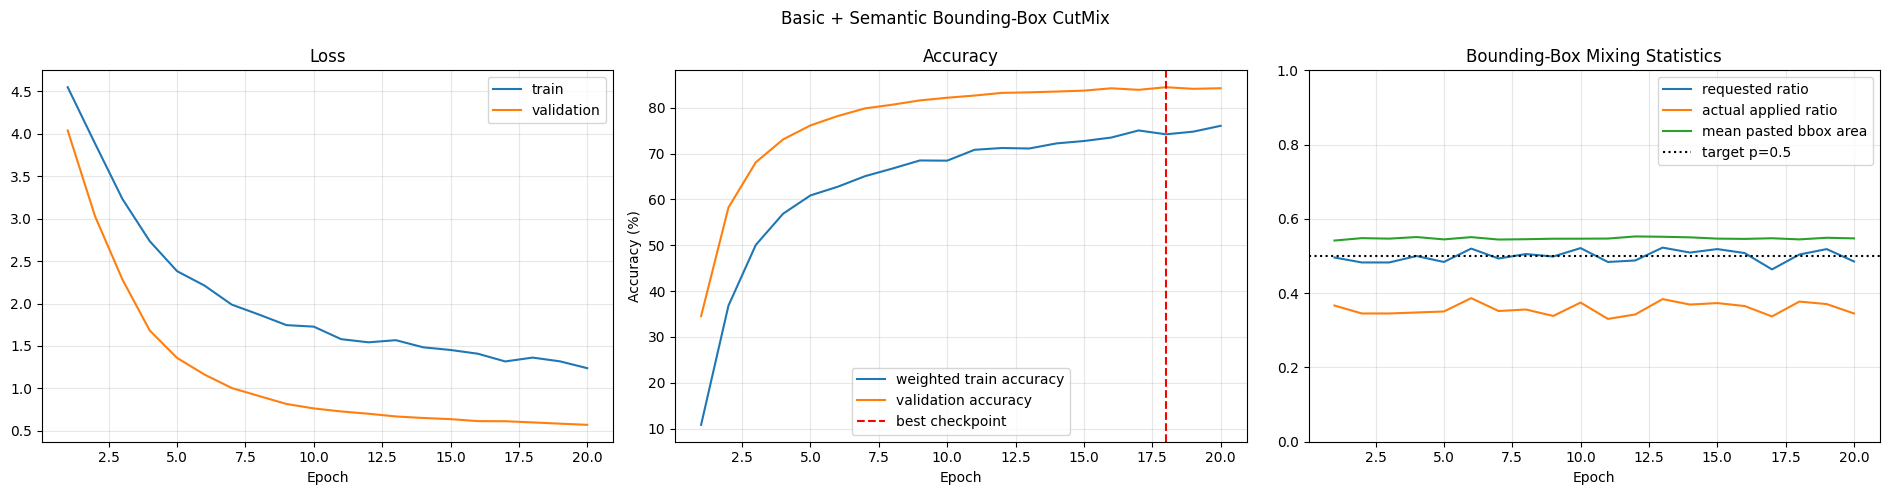

,epoch,requested_mix_ratio,actual_mix_ratio,mask_failure_batches,mean_pasted_bbox_ratio
0,1,0.4960,0.3667,97,0.5416
1,2,0.4827,0.3453,103,0.5482
2,3,0.4827,0.3453,103,0.5468
3,4,0.5000,0.3480,114,0.5511
4,5,0.4840,0.3507,100,0.5448
5,6,0.5200,0.3867,100,0.5509
6,7,0.4933,0.3520,106,0.5444
7,8,0.5053,0.3560,112,0.5453
8,9,0.4987,0.3387,120,0.5466
9,10,0.5213,0.3747,110,0.5467


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="weighted train accuracy",
)
axes[1].plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="validation accuracy",
)
axes[1].axvline(
    checkpoint["epoch"],
    color="red",
    linestyle="--",
    label="best checkpoint",
)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(
    history_df["epoch"],
    history_df["requested_mix_ratio"],
    label="requested ratio",
)
axes[2].plot(
    history_df["epoch"],
    history_df["actual_mix_ratio"],
    label="actual applied ratio",
)
axes[2].plot(
    history_df["epoch"],
    history_df["mean_pasted_bbox_ratio"],
    label="mean pasted bbox area",
)
axes[2].axhline(
    MIX_PROBABILITY,
    color="black",
    linestyle=":",
    label="target p=0.5",
)
axes[2].set_title("Bounding-Box Mixing Statistics")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)
axes[2].legend()

fig.suptitle("Basic + Semantic Bounding-Box CutMix")
fig.tight_layout()
plt.show()

display(
    history_df[[
        "epoch",
        "requested_mix_ratio",
        "actual_mix_ratio",
        "mask_failure_batches",
        "mean_pasted_bbox_ratio",
    ]].round(4)
)

## 11. 기존 두 CutMix 결과와 비교

세 조건은 모두 `Basic augmentation`, `p=0.5`, seed 42를 사용합니다. 다만 영역 크기 규칙은
각각 Beta 분포, 실제 dog mask, dog mask를 포함하는 bounding box로 다릅니다.
따라서 결과와 함께 평균 교체 면적도 확인해야 합니다.


,condition,area_rule,mix_probability,best_val_accuracy
0,Basic + random rectangle CutMix,Beta(alpha=0.2),0.5,84.8054
1,Basic + Semantic Mask CutMix,DeepLab dog mask area,0.5,84.0597
2,Basic + Semantic BBox CutMix,DeepLab dog bounding-box area,0.5,84.4908


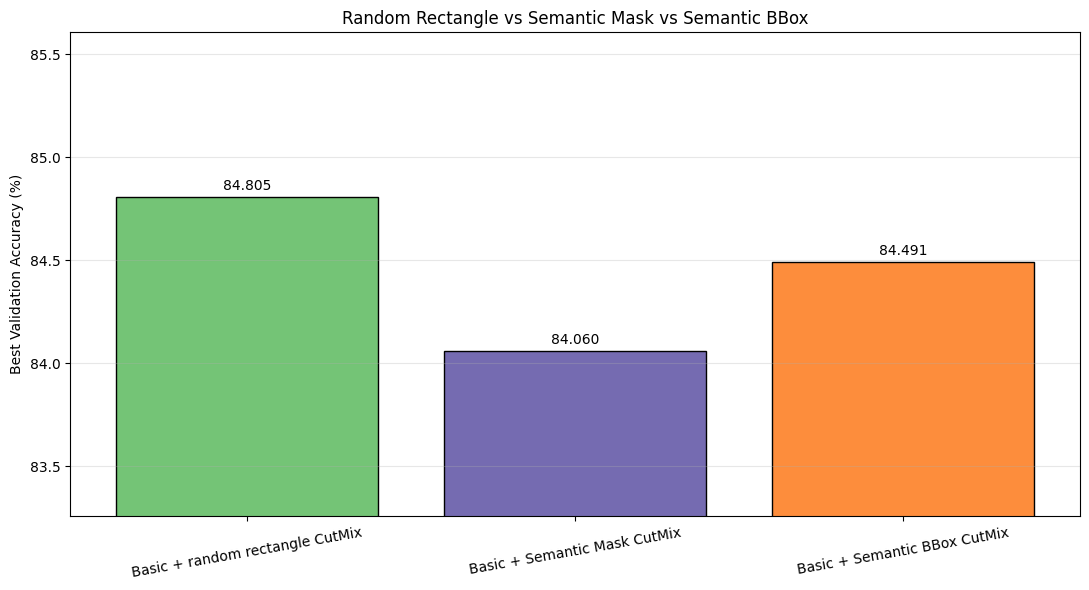

In [12]:
if not REFERENCE_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"기존 비교 CSV를 찾을 수 없습니다: {REFERENCE_SUMMARY_PATH}"
    )
if not SEMANTIC_MASK_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Semantic Mask checkpoint를 찾을 수 없습니다: "
        f"{SEMANTIC_MASK_CHECKPOINT_PATH}"
    )

reference_summary_df = pd.read_csv(REFERENCE_SUMMARY_PATH)
reference_row = reference_summary_df.loc[
    reference_summary_df["experiment"] == REFERENCE_EXPERIMENT
]
if len(reference_row) != 1:
    raise RuntimeError(
        f"{REFERENCE_EXPERIMENT} 행을 정확히 하나 찾지 못했습니다."
    )

reference_best_accuracy = float(
    reference_row.iloc[0]["best_val_accuracy"]
)
semantic_mask_checkpoint = torch.load(
    SEMANTIC_MASK_CHECKPOINT_PATH,
    map_location="cpu",
)
semantic_mask_best_accuracy = float(
    semantic_mask_checkpoint["val_accuracy"]
)
semantic_bbox_best_accuracy = float(checkpoint["val_accuracy"])

comparison_df = pd.DataFrame([
    {
        "condition": "Basic + random rectangle CutMix",
        "area_rule": "Beta(alpha=0.2)",
        "mix_probability": 0.5,
        "best_val_accuracy": reference_best_accuracy,
    },
    {
        "condition": "Basic + Semantic Mask CutMix",
        "area_rule": "DeepLab dog mask area",
        "mix_probability": 0.5,
        "best_val_accuracy": semantic_mask_best_accuracy,
    },
    {
        "condition": "Basic + Semantic BBox CutMix",
        "area_rule": "DeepLab dog bounding-box area",
        "mix_probability": MIX_PROBABILITY,
        "best_val_accuracy": semantic_bbox_best_accuracy,
    },
])
display(comparison_df.round(4))
comparison_df.to_csv(
    RESULT_DIR / "comparison.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    comparison_df["condition"],
    comparison_df["best_val_accuracy"],
    color=["#74c476", "#756bb1", "#fd8d3c"],
    edgecolor="black",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
minimum = comparison_df["best_val_accuracy"].min()
maximum = comparison_df["best_val_accuracy"].max()
ax.set_ylim(minimum - 0.8, maximum + 0.8)
ax.set_ylabel("Best Validation Accuracy (%)")
ax.set_title("Random Rectangle vs Semantic Mask vs Semantic BBox")
ax.tick_params(axis="x", rotation=10)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(COMPARISON_PATH, dpi=200, bbox_inches="tight")
plt.show()


## 12. 해석 기준과 한계

1. **mask와 bounding box의 차이**
   - Semantic Mask CutMix는 강아지 윤곽 픽셀만 교체합니다.
   - Semantic Bounding-Box CutMix는 강아지를 포함한 사각형 전체를 교체하므로 주변 배경도
     함께 이동합니다.

2. **label 가중치**
   - donor label 비율은 실제 교체한 `bbox_height × bbox_width / (224 × 224)`입니다.
   - mask 면적을 사용하면 실제 바뀐 픽셀 수와 label 비율이 달라지므로 사용하지 않습니다.

3. **기존 CutMix와의 연결**
   - 둘 다 사각형을 교체하지만 기존 CutMix는 Beta 분포와 무작위 중심으로 사각형을 정하고,
     이번 방식은 DeepLab이 찾은 dog 위치와 크기로 사각형을 정합니다.

4. **비교의 한계**
   - 세 방법의 교체 면적 분포가 다르고 seed 42 단일 실행이므로 작은 차이를 확정적인
     우위로 해석하지 않습니다.


일단 새 노트북을 하나 만들어서 bounding mask 이외의 영역은 검은 배경으로 밀어버리고 basic + 0.2 0.5 cutmix로 학습하는거 하나 해보자